# Proyecto 1: Relación Minutos Ingreso  
**Integrantes**:
- William Ávila R
- Luz Angela Rojas Prieto
- Milena Páramo
- Eliana Carolina Poveda.  

**Objetivo**  

Identificar si existe una relación entre el total de minutos usados por el cliente y sus ingresos totales con el fin de apoyar al equipo directivo de una empresa de telecomunicaciones en la toma de decisiones informadas que contribuyan al mejoramiento de su portafolio de productos y servicios. Para lo anterior tendremos en cuenta una base de datos con las siguientes variables:

**totrev**: Ingresos del cliente.  
**totmou**: Total de minutos usados por el cliente.  
**creditcd**: Indicador de tarjeta de crédito.  
**eqpdays**: Número de días (antigüedad) del equipo actual.   
**Customer_ID:** Indentificación del cliente.


## Importar base de datos 

In [193]:
import requests
import pandas as pd

# URL del archivo CSV
url = "https://raw.githubusercontent.com/Izainea/seminario-de-programacion/master/Cuadernos/Clase%202/Bases/Credito_dias.csv"

# Realiza la petición para descargar el archivo CSV
response = requests.get(url)

# Verifica si la petición fue exitosa (200==éxito)
if response.status_code == 200:
    # Guarda el archivo CSV localmente
    with open('archivo.csv', 'wb') as file:
        file.write(response.content)
    
    # Leer el CSV usando pandas
    df = pd.read_csv('archivo.csv')

    #Exportar a excel
    df.to_excel(('Minutos Ingreso.xlsx'),index=False)
else:
    print(f"Error al descargar el archivo: {response.status_code}")


## Análisis Exploratorio.   
Uso de algunos métodos para explorar la base head(); sample; columns; dtypes; info(); describe()

In [195]:
# Muestra las primeras filas del CSV
print(df.head())  

df.info()

    totmou   totrev creditcd  eqpdays  Customer_ID
0   7269.0   906.58        Y      371      1082423
1  13552.0  1172.25        N       83      1069232
2   4152.0   577.39        Y      675      1031705
3   1863.0   294.26        Y      218      1089806
4   4155.0   433.16        N      222      1076695
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   totmou       10000 non-null  float64
 1   totrev       10000 non-null  float64
 2   creditcd     9848 non-null   object 
 3   eqpdays      10000 non-null  int64  
 4   Customer_ID  10000 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 390.8+ KB


El archivo contiene un total de 10000 observaciones, 5 variables: dos tipo decimal (total ingresos y total minutos usados) y dos tipo entero (días de antiguedad y Customer ID), contiene también una variable categórica indicador de tarjeta de crédito, y en la variable creditcd se evidencian 9848 no nulos, lo cual se tendrá en cuenta más adelante. A continuación se exponen las estadísticas descriptivas de cada variable:

In [197]:
# análisis de estadísticas descriptivas para variables numéricas
columns_num= ['totmou','totrev','eqpdays']
df[columns_num].describe().round(2)


,totmou,totrev,eqpdays
count,10000.00,10000.00,10000.00
mean,7692.80,1042.13,386.79
std,8657.92,857.14,252.72
min,0.00,11.10,-5.00
25%,2576.00,526.79,210.00
50%,5262.00,820.24,338.00
75%,9823.25,1272.97,522.00
max,163264.18,13426.60,1823.00


Se observan datos negativos en la variable eqpdays que no tiene sentido considerando que la variable indica antigüedad en días del equipo actual. Por tal motivo se toma el valor absoluto de la variable:

In [199]:
df.sample()

,totmou,totrev,creditcd,eqpdays,Customer_ID
2927,18727.0,2295.74,Y,811,1017667


In [200]:
df['eqpdays_abs'] = df['eqpdays'].abs()
df['eqpdays_abs'].describe().round(2)

count    10000.00
mean       386.80
std        252.71
min          0.00
25%        210.00
50%        338.00
75%        522.00
max       1823.00
Name: eqpdays_abs, dtype: float64

## Limpieza de datos

In [202]:
#Mostrar valores nulos por cada columna
display(df.isnull().sum().head())


totmou           0
totrev           0
creditcd       152
eqpdays          0
Customer_ID      0
dtype: int64

In [203]:
#7 Eliminar filas con valores nulos
df = df.dropna()  
df.shape

(9848, 6)

In [204]:
# Nuevo df
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9848 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   totmou       9848 non-null   float64
 1   totrev       9848 non-null   float64
 2   creditcd     9848 non-null   object 
 3   eqpdays      9848 non-null   int64  
 4   Customer_ID  9848 non-null   int64  
 5   eqpdays_abs  9848 non-null   int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 538.6+ KB


## Importar Librerías

In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

## Análisis Exploratorio.   
Usamos histogramas para visualizar la distribución de las variables numéricas: totmou (minutos totales), totrev (ingresos totales) y eqpdays (días con el equipo actual) y diagrama de barras para creditcd.

### Minutos usados por cliente

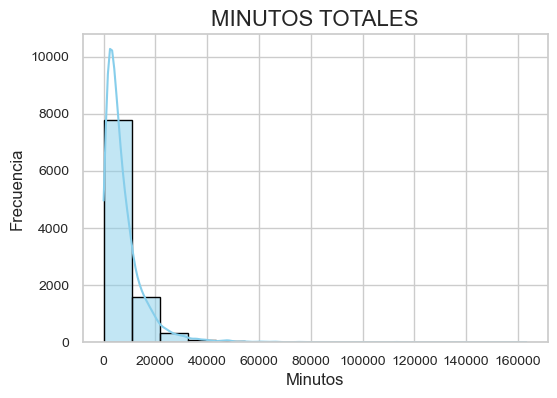

count      9848.00
mean       7697.90
std        8662.01
min           0.00
25%        2575.00
50%        5261.50
75%        9842.00
max      163264.18
Name: totmou, dtype: float64


In [209]:
# Establecer el estilo elegante de Seaborn
sns.set(style="whitegrid")

# Crear la figura del histograma
plt.figure(figsize=(6, 4))

# Crear el histograma usando seaborn
sns.histplot(df['totmou'], bins=15, kde=True, color="skyblue", edgecolor="black")

# Añadir etiquetas y título
plt.title("MINUTOS TOTALES", fontsize=16)
plt.xlabel("Minutos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

# Mejorar el diseño de los ejes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Mostrar el gráfico
plt.show()

# Mostrar estadísticas básicas de la columna 'Minutos usados por el cliente'
estadisticas1 = df['totmou'].describe().round(2)

# Mostrar el resultado
print(estadisticas1)

El total de minutos usados por el cliente estan concentrados en la categoría 0 - 10000, el 75% de los datos están ubicados por debajo de 9823.25 hay valores atípicos por encima de 40000 que afectan la distribución de los datos, el valor máximo es 163264

### Ingresos totales

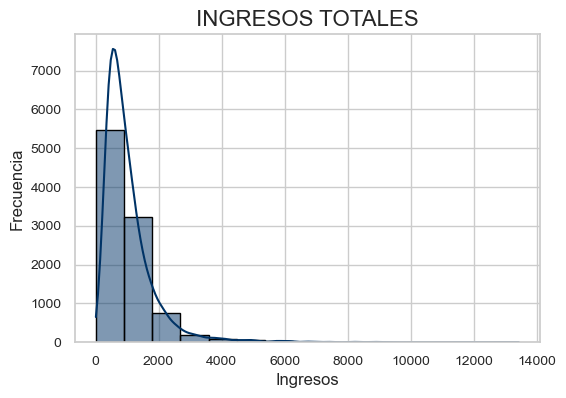

count     9848.00
mean      1042.30
std        857.95
min         11.10
25%        526.63
50%        820.96
75%       1272.97
max      13426.60
Name: totrev, dtype: float64


In [212]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.histplot(df['totrev'], bins=15, kde=True, color="#003366", edgecolor="black")
plt.title("INGRESOS TOTALES", fontsize=16)
plt.xlabel("Ingresos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()
estadisticas2 = df['totrev'].describe().round(2)
print(estadisticas2)

Los ingresos de los clientes están concentrados en la categoría 0 - 1000 usd, el 75% de los ingresos son menores a 1272.97 usd con una media de 1042.13 que está siendo afectada por valores atípicos.

### Tarjeta Crédito

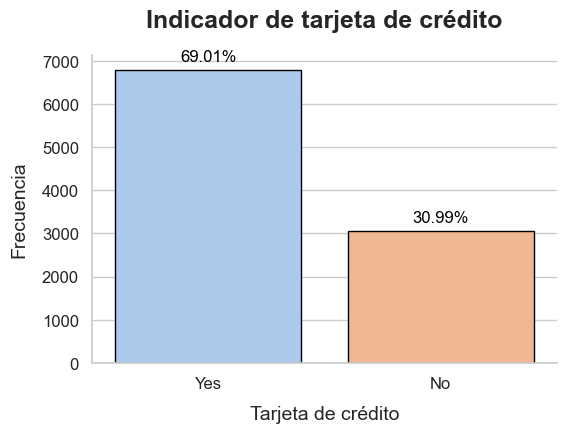

In [215]:
# Cambiar los nombres de las categorías en el DataFrame
df['creditcd'] = df['creditcd'].replace({'Y': 'Yes', 'N': 'No'})

# Contar la frecuencia de cada categoría
frecuencia = df['creditcd'].value_counts().reset_index()
frecuencia.columns = ['creditcd', 'Frecuencia']

# Calcular el porcentaje
frecuencia['Porcentaje'] = (frecuencia['Frecuencia'] / frecuencia['Frecuencia'].sum()) * 100

sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.barplot(x='creditcd', y='Frecuencia', data=frecuencia,hue='creditcd',palette='pastel', edgecolor='black')

# Añadir las etiquetas de porcentaje encima de cada barra
for index, row in frecuencia.iterrows():
    ax.text(index, row['Frecuencia'] + 200, f"{row['Porcentaje']:.2f}%", color='black', ha="center", fontsize=12)

plt.title('Indicador de tarjeta de crédito', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tarjeta de crédito', fontsize=14, labelpad=10)
plt.ylabel('Frecuencia', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()
plt.show()

El grafico muestra que 69,01% de los clientes tienen tarjeta de crédito vs el 30.99% que no tienen.

### Antigüedad 

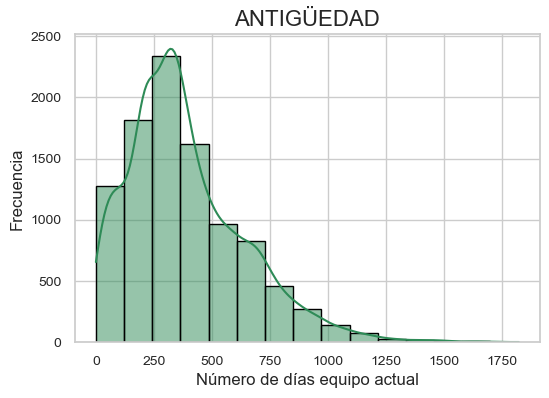

count    9848.00
mean      386.99
std       252.46
min         0.00
25%       210.00
50%       338.00
75%       523.00
max      1823.00
Name: eqpdays_abs, dtype: float64


In [218]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.histplot(df['eqpdays_abs'], bins=15, kde=True, color="#2e8b57", edgecolor="black")
plt.title("ANTIGÜEDAD", fontsize=16)
plt.xlabel("Número de días equipo actual", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()
estadisticas3 = df['eqpdays_abs'].describe().round(2)
print(estadisticas3)

Una media de 386.80 días con el equipo actual, el 75% de las observaciones están por debajo de 522 con un máximo de 1823 días.

## Diagrama de Dispersión 

Exploraremos las correlaciones entre las variables númericas en nuestro DataFrame

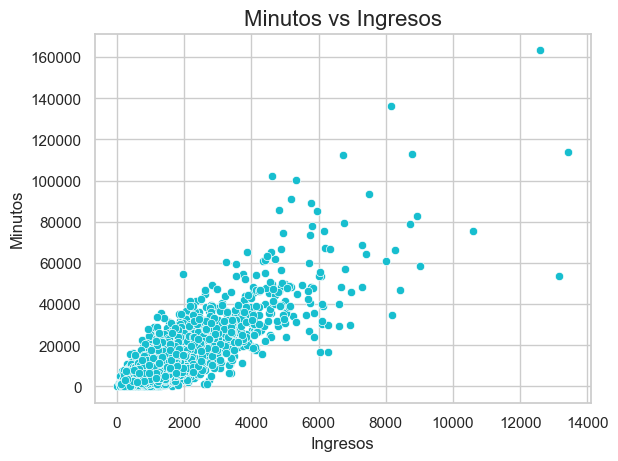

In [222]:
# Crear el gráfico de dispersión
sns.scatterplot(x='totrev', y='totmou', data=df,color='#17becf')
plt.title('Minutos vs Ingresos', fontsize=16)
plt.xlabel('Ingresos', fontsize=12)
plt.ylabel('Minutos', fontsize=12)
plt.show()

In [223]:
#Matriz de correlación
df[columns_num].corr()

,totmou,totrev,eqpdays
totmou,1.000000,0.835279,-0.111589
totrev,0.835279,1.000000,0.060361
eqpdays,-0.111589,0.060361,1.000000


Según el gráfico y la matriz anterior si existe una relación entre el total de minutos usados con la compañía **totmou** y el ingreso total de los clientes **totrev** indica que los clientes con mayores ingresos tienden a utilizar más minutos. La correlación de 83% identificada en la matriz puede generar algún tipo de sesgo en el análisis por lo que analizaremos los datos usando una regresión lineal con el fin de confirmar si cuando una persona tiene un mayor ingreso, entonces es mayor la utilización de minutos. 

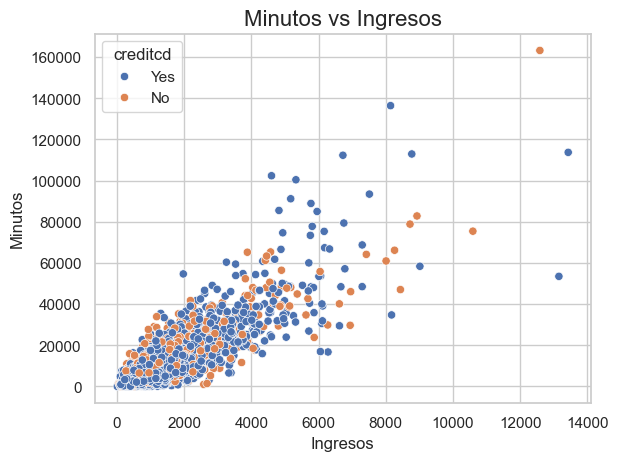

In [225]:
# Crear el gráfico de dispersión, incluyendo la variable creditcd
sns.scatterplot(x='totrev', y='totmou',hue='creditcd', data=df,palette='deep')
plt.title('Minutos vs Ingresos', fontsize=16)
plt.xlabel('Ingresos', fontsize=12)
plt.ylabel('Minutos', fontsize=12)
plt.show()

Comparando este último gráfico de dispersión con el generado inicialmente se evidencia que el hecho de tener tarjeta de crédito no afecta ninguna de las dos variables (Ingresos y minutos).

## **Preparación de los datos.**  
Primero, Primero, convertimos la variable creditcd a valores numéricos (1 si tiene tarjeta de crédito y 0 si no tiene), necesitamos asegurarnos de que no haya valores nulos en las variables que vamos a usar para los modelo.

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9848 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   totmou       9848 non-null   float64
 1   totrev       9848 non-null   float64
 2   creditcd     9848 non-null   object 
 3   eqpdays      9848 non-null   int64  
 4   Customer_ID  9848 non-null   int64  
 5   eqpdays_abs  9848 non-null   int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 538.6+ KB


In [239]:
# Convertir la columna 'creditcd' a numérica (1 para Yes, 0 para No)
df['creditcd'] = df['creditcd'].replace({'Yes': 1, 'No': 0})
df['creditcd'].value_counts()

C:\Users\user\AppData\Local\Temp\ipykernel_22972\3354982632.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['creditcd'] = df['creditcd'].replace({'Yes': 1, 'No': 0})


creditcd
1    6796
0    3052
Name: count, dtype: int64

In [240]:
# Revisar si hay valores nulos en las columnas involucradas
df.isnull().sum()

totmou         0
totrev         0
creditcd       0
eqpdays        0
Customer_ID    0
eqpdays_abs    0
dtype: int64

## Regresión Lineal   
INGRESOS TOTALES (totrev) Y LOS MINUTOS TOTALES USADOS POR LOS CLIENTES (totmou)

**Definir las variables dependientes e independientes.**

In [241]:
# Definir la variable dependiente (y) y la independiente (X)
X = df[['totrev']]  # Ingresos Totales como variable independiente
y = df['totmou']    # Minutos Totales como variable dependiente

**División de los datos en entrenamiento y prueba**  
Dividimos los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.

In [243]:
# CODIGO PARA DIVIDIR LOS DATOS EN ENTRENAMIENTO Y TEST

from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train e y_train contienen los datos de entrenamiento
# X_test e y_test contienen los datos de prueba

**Ajuste del modelo de regresión lineal**  
Utilizamos el modelo de regresión lineal de la librería sklearn para ajustar el modelo con los datos de entrenamiento.

Mean Squared Error (MSE): 19456476.71085977
R-squared (R2): 0.6344989217101299
Intersección: -1180.073142749574
Pendiente: 8.54091037620266


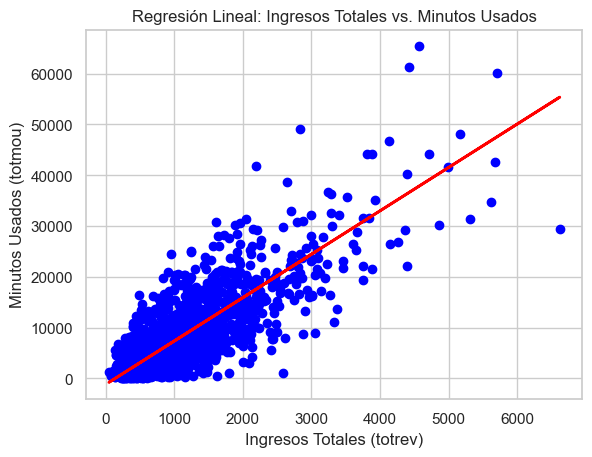

In [245]:
# prompt: CREAR CODIGO DE MODELO DE REGRESIÓN LINEAL Y AGREGA AL FINAL LA INTERPRETACIÓN DEL MODELO

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Crear un objeto de regresión lineal
model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

# Hacer predicciones con los datos de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

# Obtener la intersección y la pendiente de la línea de regresión
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intersección: {intercept}")
print(f"Pendiente: {slope}")

# Gráfico de la línea de regresión
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.xlabel('Ingresos Totales (totrev)')
plt.ylabel('Minutos Usados (totmou)')
plt.title('Regresión Lineal: Ingresos Totales vs. Minutos Usados')
plt.show()

#### **INTERPRETACIÓN DEL MODELO**


##### * **Pendiente (slope):** La pendiente representa el cambio en los minutos totales usados (totmou) por cada unidad de cambio en los ingresos totales (totrev). En este caso, una pendiente de 'slope' significa que por cada unidad adicional de ingresos, se espera que el número de minutos usados aumente en 8.315291587988725 unidades.

##### * **Intersección (intercept):** La intersección representa el valor esperado de los minutos totales usados cuando los ingresos totales son cero. Probablemente este valor no tenga relevancia en el contexto de este ejercicio.

##### * **R-cuadrado (R2):**  R-cuadrado es una medida que va de 0 a 1 y expresa que tan bien el modelo se ajusta a los datos. En este caso el (R2): 0.697039724676021 significa que aproximadamente el 69,7% de la variabilidad de la variable dependiente «minutos totales utilizados» puede ser explicada por la variable independiente «ingresos totales».El porcentaje sugiere una relación moderadamente fuerte entre las variables independientes y dependientes, es decir, que el modelo captura una parte significativa del patrón de los datos, pero puede mejorar.
##### Es necesario valorar la métrica del MSE para una evaluación más completa del rendimiento del modelo.

##### * **MSE:** El MSE (Error Cuadrático Medio) representa la diferencia cuadrática media entre los valores predichos y los valores reales en un modelo de regresión. En términos más sencillos, mide el error medio de las predicciones de su modelo.
##### El valor MSE de 23448396.41 es relativamente grande. Esto sugiere que las predicciones del modelo, en promedio, se desvían sustancialmente de los valores reales. Esta desviación significativa indica que el modelo podría no estar capturando con precisión la relación entre las variables.

## Regresión Logistica
RELACIÓN ENTRE TENER UNA TARJETA DE CRÉDITO (creditcd) CON LOS MINUTOS TOTALES USADOS (totmou)

**Definir las variables dependientes e independientes.**

In [306]:
# Definir la variable dependiente (y) y la independiente (X)
X = df[['totmou']]  # Minutos Totales como variable independiente
y = df['creditcd']    # Indicador de tarjeta de crédito como variable dependiente

**División de los datos en entrenamiento y prueba**  
Dividimos los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.

In [308]:
# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Ajuste del modelo de regresión logistica**  
Utilizamos el modelo de regresión logistica de la librería sklearn para ajustar el modelo con los datos de entrenamiento.

In [314]:
# Importar el modelo de Regresión Logística
from sklearn.linear_model import LogisticRegression

# Crear una instancia del modelo
model = LogisticRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones con el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo (usando métricas como precisión, recall, F1-score)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precisión: {accuracy}")
print(f"Precisión (Precision): {precision}")
print(f"Sensibilidad (Recall): {recall}")
print(f"Puntuación F1: {f1}")

# Matriz de confusión
confusion_mat = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(confusion_mat)

Precisión: 0.6949238578680204
Precisión (Precision): 0.6949238578680204
Sensibilidad (Recall): 1.0
Puntuación F1: 0.8200059898173105
Matriz de confusión:
[[   0  601]
 [   0 1369]]


**Visualizacion de la curva ROC**

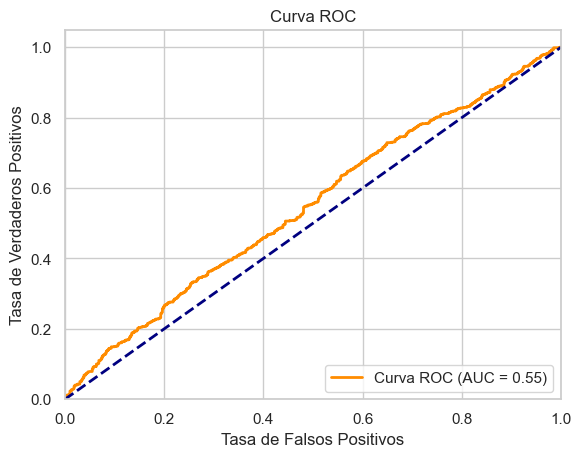

In [317]:
# Visualizar la curva ROC para evaluar la calidad del modelo

from sklearn.metrics import roc_curve, auc

# Obtener las probabilidades de predicción para la clase positiva (creditcd_numeric = 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calcular el área bajo la curva (AUC)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

#### **INTERPRETACIÓN DEL MODELO**


##### **Precisión**: el 67,65% de las predicciones fueron correctas. Se trata de una medida general de rendimiento, pero puede inducir a error si las clases están desequilibradas. De todas las instancias predichas como positivas, el 67,65% fueron realmente positivas. Esta métrica se centra en la precisión de las predicciones positivas.

##### **Recall (Sensibilidad)**: De todas las instancias positivas reales, el 99,85% se predijeron correctamente como positivas. Esta métrica se centra en la capacidad del modelo para identificar casos positivos.

##### **Puntuación F1**: 0,8069 representa la media armónica de la precisión y la recuperación, proporcionando una medida equilibrada del rendimiento. Tiene en cuenta tanto la precisión de las predicciones positivas como la capacidad del modelo para identificar casos positivos.

##### **Matriz de confusión**:  
##### Verdaderos positivos (TP): 1352 (predicciones positivas correctas)
##### Verdaderos negativos (NT): 1 (predicción negativa correcta)
##### Falsos positivos (FP): 645 (predicción positiva incorrecta)
##### Falsos negativos (FN): 2 (predicción negativa incorrecta)

##### **Valor de Curva de ROC**: El valor de 0.55 en el modelo de regresión logística indica que la relación entre tener una tarjeta de c´redito y los munutos totales usados es muy débil y que el modelo no es muy preciso en la predicción de si un cliente tiene tarjeta de crédito basádose en sus minutos de uso.